In [1]:
# LIBRERIAS

import numpy as np
import pandas as pd
import mlflow



from scipy.stats import poisson
from sklearn.metrics import log_loss
from scipy.optimize import differential_evolution
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go


from tqdm import tqdm
from tqdm import TqdmWarning
from IPython.display import display
from typing import Sequence, cast
import os
import hashlib
import json
import tempfile
from pathlib import Path

import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# CONFIGURACIÓN DE MLFLOW (SQLite con ruta absoluta respecto al cwd del kernel)

_mlflow_db_path = (Path.cwd() / "mlflow_experimentos.db").resolve()
_mlflow_sqlite_uri = "sqlite:///" + str(_mlflow_db_path).replace("\\", "/")
mlflow.set_tracking_uri(_mlflow_sqlite_uri)
mlflow.set_experiment("Championship_Maher_Model")
print(f"MLflow tracking DB (ruta absoluta): {_mlflow_db_path}")

2026/03/27 16:53:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/27 16:53:03 INFO mlflow.store.db.utils: Updating database tables
2026/03/27 16:53:05 INFO mlflow.tracking.fluent: Experiment with name 'Championship_Maher_Model' does not exist. Creating a new experiment.


MLflow tracking DB (ruta absoluta): /home/borjatortuero/Escritorio/Master/TFM/notebooks/mlflow_experimentos.db


In [3]:
# Directorio del notebook 
base_path = os.getcwd()
# Construir ruta relativa
csv_path = os.path.join(base_path, '..', 'Data', 'Segunda_inglesa_data.csv')
# Normalizar la ruta 
csv_path = os.path.abspath(csv_path)

# Cargamos el fichero
df = pd.read_csv(csv_path)

with open(csv_path, "rb") as _csv_f:
    CSV_DATA_SHA256 = hashlib.sha256(_csv_f.read()).hexdigest()

temp_date = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df['Date'] = pd.to_datetime(temp_date.dt.strftime('%Y-%m-%d') + ' ' + df['Time'].astype(str))

# Ordenamos por la nueva columna Date (que ya tiene fecha y hora)
df = df.sort_values('Date').reset_index(drop=True)

# Calcular el número de partido de la temporada para cada equipo
team_game_count = {}
matchdays = []

for idx, row in df.iterrows():
    h, a = row['HomeTeam'], row['AwayTeam']
    # Contamos cuántos partidos ha jugado cada uno hasta ahora
    count_h = team_game_count.get(h, 0) + 1
    count_a = team_game_count.get(a, 0) + 1

    # La jornada real del partido es el máximo de ambos (por si hay partidos aplazados)
    jornada = max(count_h, count_a)
    matchdays.append(jornada)

    # Actualizar contador para el siguiente partido
    team_game_count[h] = count_h
    team_game_count[a] = count_a

df['Jornada'] = matchdays

# Limpieza de columnas no comunes
df.dropna(inplace=True, axis=1)

df

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Jornada
0,E1,2023-08-04 20:00:00,20:00,Sheffield Weds,Southampton,1,2,A,0,1,...,0.25,1.91,1.99,1.93,2.00,1.97,2.00,1.88,1.95,1
1,E1,2023-08-05 15:00:00,15:00,Blackburn,West Brom,2,1,H,2,0,...,0.00,2.05,1.85,2.07,1.85,2.10,1.88,2.03,1.82,1
2,E1,2023-08-05 15:00:00,15:00,Bristol City,Preston,1,1,D,0,0,...,-0.25,1.82,2.08,1.84,2.08,1.88,2.15,1.80,2.04,1
3,E1,2023-08-05 15:00:00,15:00,Middlesbrough,Millwall,0,1,A,0,0,...,-0.25,1.80,2.10,1.83,2.10,1.91,2.14,1.85,1.99,1
4,E1,2023-08-05 15:00:00,15:00,Norwich,Hull,2,1,H,1,1,...,-0.75,2.06,1.84,2.05,1.86,2.10,1.91,2.01,1.83,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099,E1,2025-05-03 12:30:00,12:30,Sheffield United,Blackburn,1,1,D,0,0,...,0.00,1.89,2.01,1.90,2.01,1.91,2.11,1.84,2.04,92
1100,E1,2025-05-03 12:30:00,12:30,Swansea,Oxford,3,3,D,1,1,...,-1.00,2.02,1.88,2.03,1.88,2.08,1.89,2.00,1.85,92
1101,E1,2025-05-03 12:30:00,12:30,Norwich,Cardiff,4,2,H,3,0,...,-1.00,1.86,2.04,1.88,2.03,1.96,2.06,1.86,1.99,92
1102,E1,2025-05-03 12:30:00,12:30,Plymouth,Leeds,1,2,A,1,0,...,1.75,1.99,1.91,1.97,1.92,1.99,1.97,1.95,1.90,92


### **Visualización preliminar**

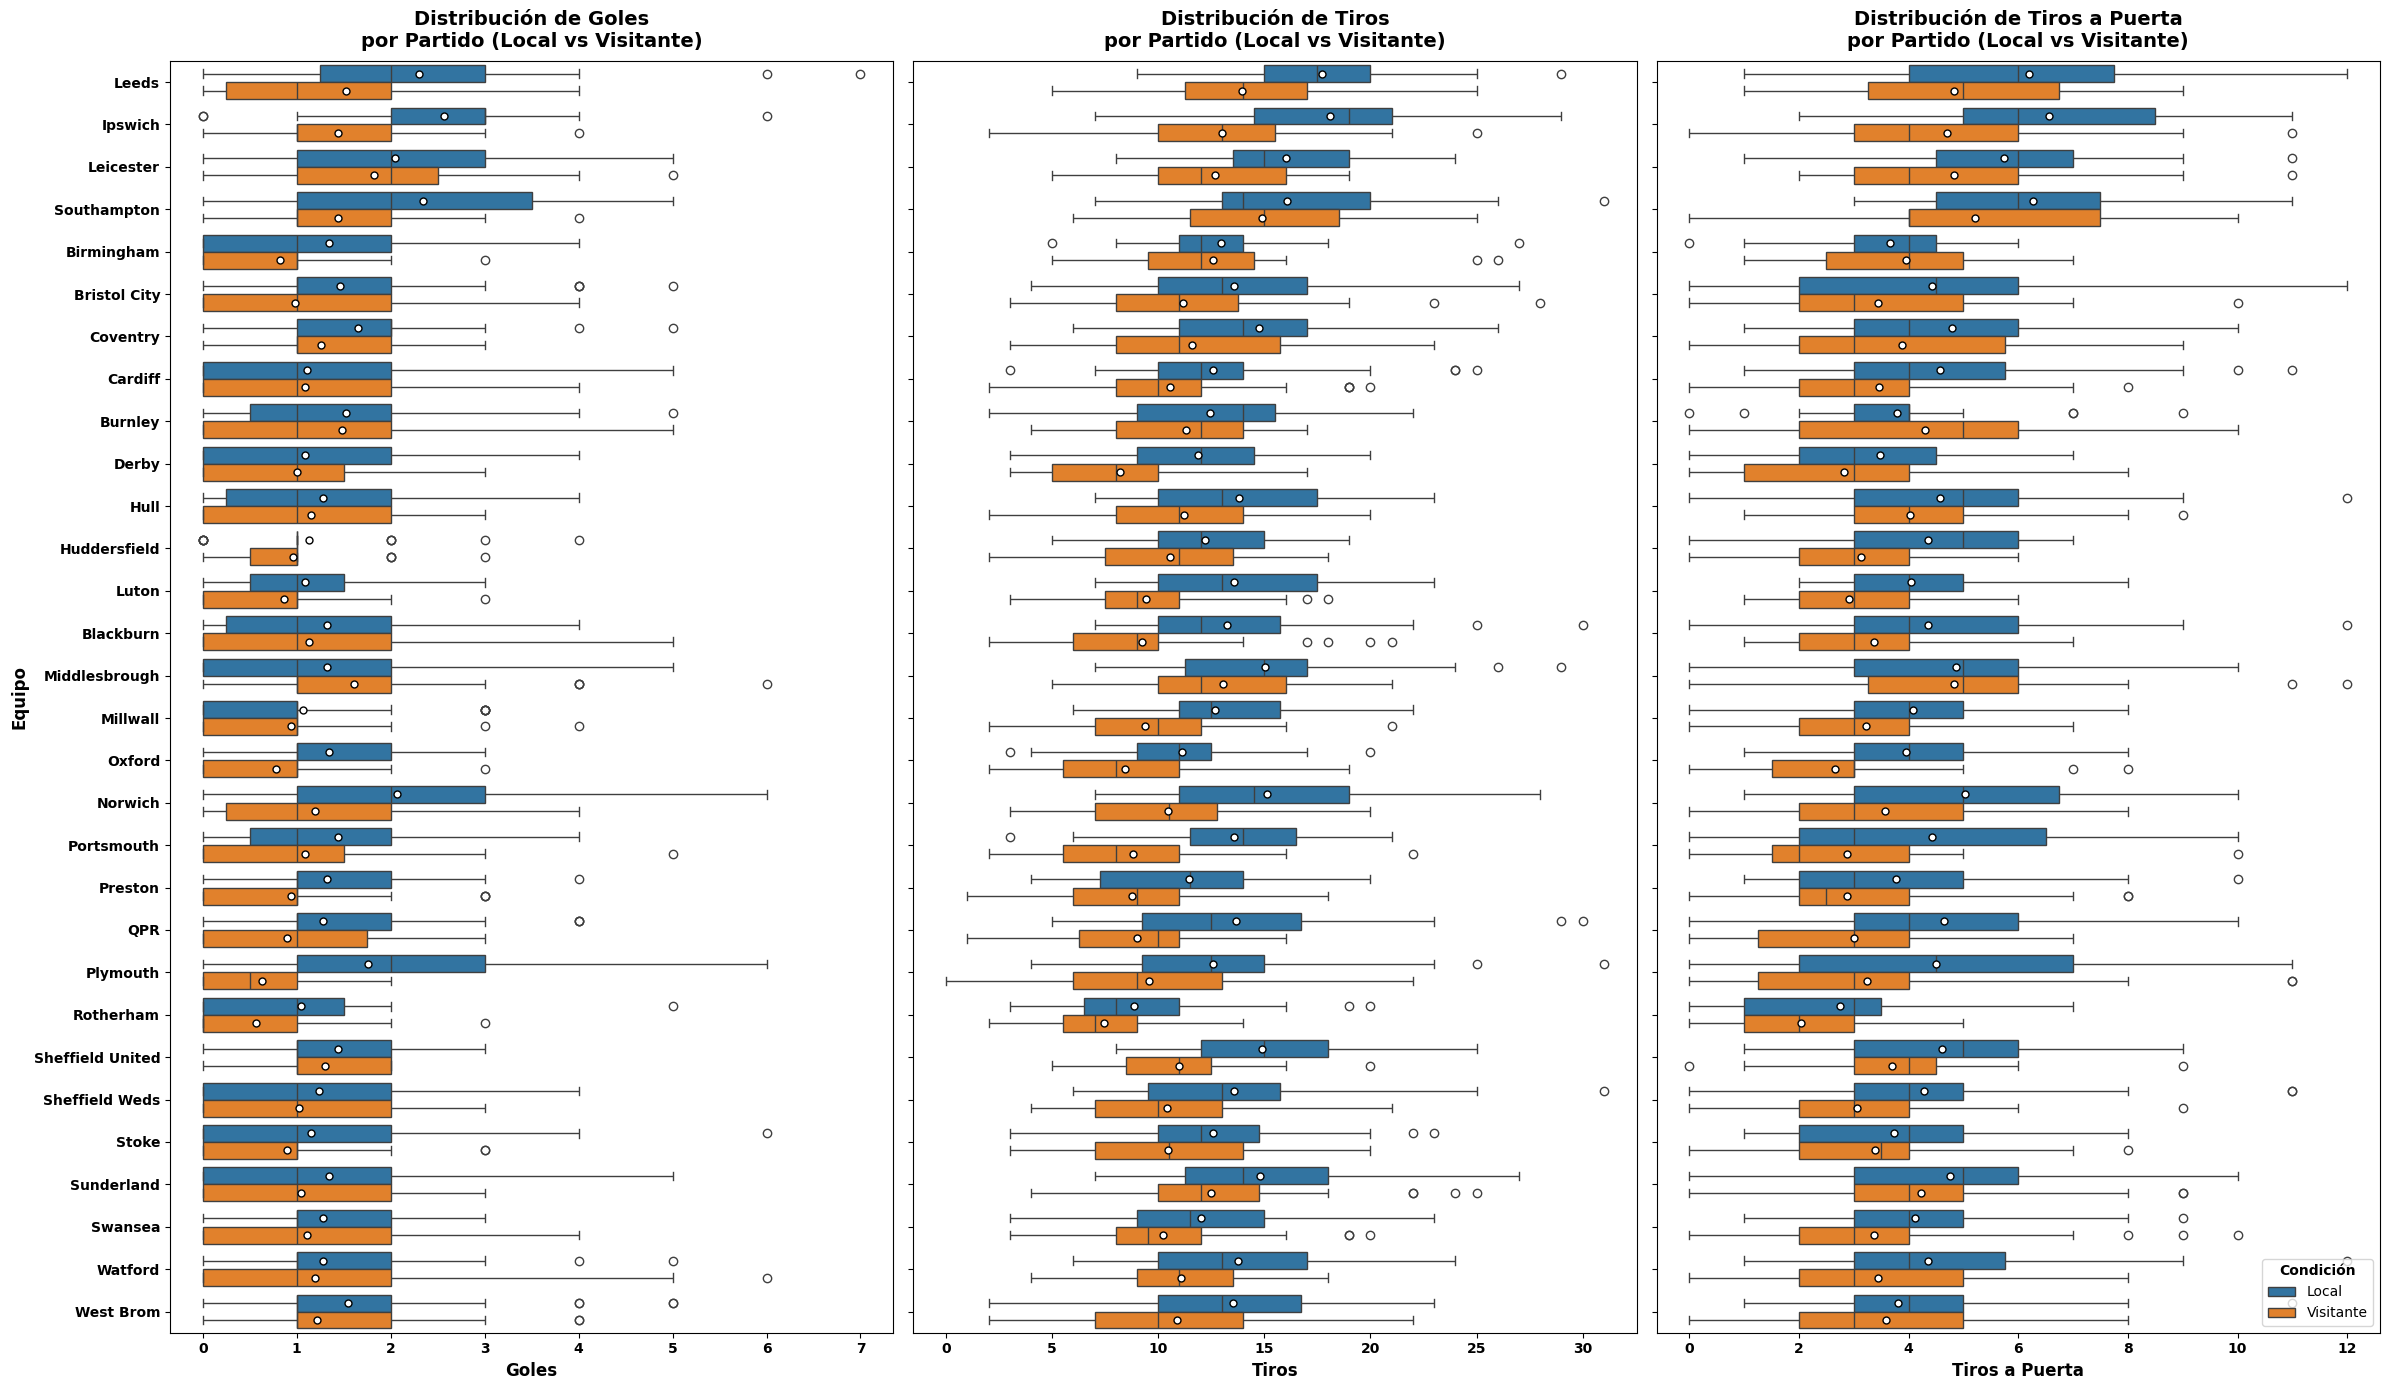

In [4]:
# Preparar los datos: extraer, renombrar y añadir la condición (Local/Visitante)
df_home = df[['HomeTeam', 'FTHG', 'HS', 'HST']].rename(
    columns={'HomeTeam': 'Team', 'FTHG': 'Goles', 'HS': 'Tiros', 'HST': 'Tiros a Puerta'}
)
df_home['Condición'] = 'Local'

df_away = df[['AwayTeam', 'FTAG', 'AS', 'AST']].rename(
    columns={'AwayTeam': 'Team', 'FTAG': 'Goles', 'AS': 'Tiros', 'AST': 'Tiros a Puerta'}
)
df_away['Condición'] = 'Visitante'

# Unir ambos DataFrames
df_stats = pd.concat([df_home, df_away], ignore_index=True)

# Ordenar equipos por la mediana general de goles 
team_order = df_stats.groupby('Team')['Goles'].median().sort_values(ascending=False).index

# Configurar la figura con 3 subplots (1 fila, 3 columnas)
metrics = ['Goles', 'Tiros', 'Tiros a Puerta']
palette_colors = {'Local': '#1f77b4', 'Visitante': '#ff7f0e'} 

fig, axes = plt.subplots(1, 3, figsize=(24, 14), sharey=True)

# Bucle para generar los boxplots
for i, metric in enumerate(metrics):
    sns.boxplot(
        data=df_stats,
        x=metric,
        y='Team',
        hue='Condición',
        order=team_order,
        palette=palette_colors,
        ax=axes[i],
        showmeans=True, 
        meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"5"}
    )
    
    axes[i].set_title(f'Distribución de {metric}\npor Partido (Local vs Visitante)', 
                      fontsize=14, pad=10, fontweight='bold')
    axes[i].set_xlabel(metric, fontsize=12, fontweight='bold')
    
    plt.setp(axes[i].get_xticklabels(), fontweight='bold')
    
    if i == 0:
        axes[i].set_ylabel('Equipo', fontsize=12, fontweight='bold')
        plt.setp(axes[i].get_yticklabels(), fontweight='bold')
    else:
        axes[i].set_ylabel('')
        
    # Limpiar las leyendas redundantes y configurar la final 
    if i < 2:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title='Condición', title_fontproperties={'weight': 'bold'}, loc='lower right')

# Ajustar márgenes generales
plt.tight_layout()
plt.show()

In [5]:
# Preparar los datos de resultados

# Mapeamos los códigos originales (H, D, A) a nombres más descriptivos
result_map = {'H': 'Victoria Local', 'D': 'Empate', 'A': 'Victoria Visitante'}
df_results = df['FTR'].map(result_map).value_counts().reset_index()
df_results.columns = ['Resultado', 'Partidos']

# Calcular porcentajes para mostrar en el gráfico
total_matches = df_results['Partidos'].sum()
df_results['Porcentaje'] = (df_results['Partidos'] / total_matches * 100).round(2)

# Crear la visualización con Plotly
fig = px.bar(
    df_results, 
    x='Resultado', 
    y='Partidos',
    text=df_results['Porcentaje'].apply(lambda x: f"<b>{x}%</b>"), 
    color='Resultado',
    color_discrete_map={
        'Victoria Local': '#2ecc71',      
        'Empate': '#95a5a6',              
        'Victoria Visitante': '#e74c3c'   
    },
    title='<b>Distribución Global de Resultados</b>'
)

fig.update_traces(insidetextanchor='middle')

# Estilizar el gráfico 
fig.update_layout(
    xaxis_title='<b>Resultado del Partido</b>',
    yaxis_title='<b>Número de Partidos</b>',
    title_font=dict(size=20, family='Arial', color='black'),
    template='plotly_white',
    showlegend=False,
    font=dict(family="Arial", size=12, color="black")
)

fig.update_xaxes(tickfont=dict(family='Arial', size=14, color='black'))
fig.update_yaxes(tickfont=dict(family='Arial', size=14, color='black'))

fig.show()

### **Ajuste de Parámetros: Robustez mediante la Mediana**

Se ha tomado la decisión técnica de utilizar la **mediana** en lugar de la media aritmética para la estimación de los parámetros de fuerza de ataque ($\alpha$) y defensa ($\beta$) en los modelos probabilísticos de Poisson.

#### Justificación Técnica
* **Presencia de Outliers**: Los diagramas de caja revelan una asimetría positiva significativa en la distribución de goles, con valores atípicos (partidos de 4, 5 o más goles) que desplazan la media hacia arriba¡.
* **Suposición de Poisson**: El modelo tradicional de Maher y su extensión de Dixon-Coles asumen que el conteo de goles sigue una distribución de Poisson donde la media es igual a la varianza. La utilización de la mediana actúa como un estimador robusto que evita la sobreestimación del potencial goleador causada por goleadas aisladas.
* **Estabilidad del Modelo**: Al centrar los parámetros en la mediana, se logra una mayor resistencia a las "anomalías" de la jornada, permitiendo que el modelo de **Dixon-Coles** se enfoque en la tendencia central de rendimiento en lugar de en eventos de baja probabilidad.

Esta decisión busca corregir la tendencia de los modelos basados en Poisson a infraestimar marcadores bajos (0-0, 1-1), alineándose con la necesidad de manejar la alta incidencia de empates identificada en el estudio.

In [6]:
# Nos quedamos con la primera temporada y mitad de la segunda para entrenar y con la mitad restante para predecir/validar
df_train = df.iloc[:-190].copy()
df_test = df.iloc[-190:].copy()

### **Modelo de Maher (1982)**

El modelo de Maher establece que el número de goles marcados por el equipo local y el visitante siguen distribuciones de **Poisson independientes**, cuyas medias ($\lambda$) se calculan cruzando la capacidad ofensiva de un equipo ($\alpha$) frente a la capacidad defensiva de su oponente ($\beta$). Su premisa fundamental es la **independencia estocástica**, asumiendo el hecho de que un equipo marque no altera la probabilidad de que el otro lo haga, permitiendo calcular la probabilidad de cualquier marcador exacto mediante el producto simple de sus probabilidades individuales: $P(X=x, Y=y) = P(X=x) \cdot P(Y=y)$

Maher, M. J. (1982). *Modelling association football scores*. Statistica Neerlandica.

[Acceso al artículo](https://doi.org/10.1111/j.1467-9574.1982.tb00782.x)

In [7]:
def predict_match_maher(row, params, avg_home_goals, avg_away_goals):
    '''
    Función que predice el resultado del partido a partir de la distribución de Poisson en función de la fuerza de ataque y de defensa de los equipos
    '''
    home = row['HomeTeam']   # equipo local
    away = row['AwayTeam']   # equipo visitante

    # Calcular Goles Esperados

    lambda_home = params.loc[home, 'Alpha_Home'] * params.loc[away, 'Beta_Away'] * avg_home_goals   # goles esperados del local
    lambda_away = params.loc[away, 'Alpha_Away'] * params.loc[home, 'Beta_Home'] * avg_away_goals   # goles esperados del visitante

    # Generar probabilidades de marcadores
    # Probabilidad de marcar k goles (considerando una distribución de Poisson) : poisson.pmf(k, lambda) -> poisson(k, lambda) = (exp(-lambda) * lambda^k) / lambda!
    # poisson.ppf(epsilon, lambda) -> Dado lambda, te dice a partir de que k (número de goles), cubres el (epsilon * 100)% de los casos (considerando una distribución de Poisson)

    epsilon = 0.9999   # Cubriremos al menos el 99.99% de los casos
    max_k_home = poisson.ppf(epsilon, lambda_home)
    max_k_away = poisson.ppf(epsilon, lambda_away)

    # Nos aseguramos de cubrir al menos hasta el máximo de los dos + 1 margen de seguridad
    max_goals = int(max(max_k_home, max_k_away)) + 1

    # Generamos el rango de goles (0, 1, 2... hasta max_goals)
    k_values = np.arange(0, max_goals)

    # Calculamos todas las probabilidades
    prob_h = poisson.pmf(k_values, lambda_home)
    prob_a = poisson.pmf(k_values, lambda_away)

    # Matriz de probabilidades
    # prob_matrix[i][j] es la probabilidad del marcador i-j (Local-Visitante)
    prob_matrix = np.outer(prob_h, prob_a)
    # Re-normalizar para que la suma sea exactamente 1.0
    prob_matrix /= prob_matrix.sum()

    # Sumar probabilidades para 1X2
    # np.tril (triángulo inferior) -> Gana Local (i > j)
    # np.triu (triángulo superior) -> Gana Visitante (i < j)
    # np.diag (diagonal) -> Empate (i = j)

    # Prob Victoria Local (suma de los elementos 'debajo' de la diagonal)
    p_home_win = np.sum(np.tril(prob_matrix, -1))

    # Prob Empate (suma de los elementos de la diagonal)
    p_draw = np.sum(np.diag(prob_matrix))

    # Prob Victoria Visitante (suma de los elementos 'encima' de la diagonal)
    p_away_win = np.sum(np.triu(prob_matrix, 1))

    return pd.Series([p_home_win, p_draw, p_away_win],
                     index=['Prob_Home', 'Prob_Draw', 'Prob_Away'])

In [8]:
# CÁLCULO DE PARÁMETROS
# Fuerza de ataque = w_goles * goles_mediana / goles_mediana_liga +  w_tiros_a_puerta * tiros_a_puerta_mediana / tiros_a_puerta_mediana_liga + w_tiros_totales * tiros_totales_mediana / tiros_totales_mediana_liga
# Fuerza de defensa = w_goles * goles_mediana_recibidos / goles_mediana_recibidos_liga +  w_tiros_a_puerta * tiros_a_puerta_mediana_recibidos / tiros_a_puerta_mediana_recibidos_liga + w_tiros_totales * tiros_totales_mediana_recibidos / tiros_totales_mediana_recibidos_liga

avg_home_goals = df_train['FTHG'].median()
avg_away_goals = df_train['FTAG'].median()
avg_home_st = df_train['HST'].median()
avg_away_st = df_train['AST'].median()
avg_home_s = df_train['HS'].median()
avg_away_s = df_train['AS'].median()

# Estadísticas en casa y fuera de casa (mediana de goles marcados/recibidos y mediana de disparos realizados/recibidos (a puerta y totales))
home_stats = df_train.groupby('HomeTeam')[['FTHG', 'HST', 'HS', 'FTAG', 'AST', 'AS']].median()
away_stats = df_train.groupby('AwayTeam')[['FTAG', 'AST', 'AS', 'FTHG', 'HST', 'HS']].median()

# Lista global para guardar la historia de la optimización
maher_history = []

# --- OPTIMIZACIÓN AVANZADA DE MAHER ---

def negative_log_likelihood_maher_3weights(opt_params, df_dataset):
    """
    Calcula el error (Log Loss) del modelo Maher variando los pesos de
    Goles / Tiros Puerta / Tiros Totales.
    Optimiza buscando maximizar la probabilidad del resultado REAL (1X2).
    """
    w_g, w_st = opt_params
    w_tot = 1.0 - w_g - w_st

    # Penalización si los pesos son inválidos (negativos)
    if w_g < 0 or w_st < 0 or w_tot < 0:
        return 9999999

    # -- CONSTRUCCIÓN DE PARÁMETROS --
    # Creamos las alfas y betas temporales con los pesos que estamos probando
    params_trial = pd.DataFrame(index=home_stats.index)

    # Fuerza Ataque Local
    params_trial['Alpha_Home'] = (
        (home_stats['FTHG'] / avg_home_goals) * w_g +
        (home_stats['HST'] / avg_home_st) * w_st +
        (home_stats['HS'] / avg_home_s) * w_tot
    )
    # Debilidad Defensa Local
    params_trial['Beta_Home'] = (
        (home_stats['FTAG'] / avg_away_goals) * w_g +
        (home_stats['AST'] / avg_away_st) * w_st +
        (home_stats['AS'] / avg_away_s) * w_tot
    )
    # Fuerza Ataque Visitante
    params_trial['Alpha_Away'] = (
        (away_stats['FTAG'] / avg_away_goals) * w_g +
        (away_stats['AST'] / avg_away_st) * w_st +
        (away_stats['AS'] / avg_away_s) * w_tot
    )
    # Debilidad Defensa Visitante
    params_trial['Beta_Away'] = (
        (away_stats['FTHG'] / avg_home_goals) * w_g +
        (away_stats['HST'] / avg_home_st) * w_st +
        (away_stats['HS'] / avg_home_s) * w_tot
    )

    # -- EVALUACIÓN DEL ERROR EN EL DATASET --
    total_log_likelihood = 0
    count_valid = 0

    # Iteramos por los partidos para ver qué tan bien predicen estos pesos
    for idx, row in df_dataset.iterrows():
        h, a = row['HomeTeam'], row['AwayTeam']
        if h not in params_trial.index or a not in params_trial.index:
            continue

        # Le pasamos los params_trial calculados con los pesos actuales
        probs = predict_match_maher(row, params_trial, avg_home_goals, avg_away_goals)

        p_home = probs['Prob_Home']
        p_draw = probs['Prob_Draw']
        p_away = probs['Prob_Away']

        # Seleccionamos la probabilidad de lo que OCURRIÓ REALMENTE
        if row['FTHG'] > row['FTAG']:
            prob_obs = p_home      # Ganó Local
        elif row['FTHG'] == row['FTAG']:
            prob_obs = p_draw   # Empate
        else:
            prob_obs = p_away   # Ganó Visitante

        # Sumamos el Log negativo
        total_log_likelihood -= np.log(max(prob_obs, 1e-9))
        count_valid += 1   # Contador de partidos válidos

    if count_valid == 0:
        return 9999999

    # Imprimir progreso
    # Referencia Score: 1.10 (33% p - Azar) | 1.06 (35% p - Básico) | 1.00 (37% p - Profesional) | 0.90 (40% p - Élite) | 0.35 (70% p - Utopía)
    score = total_log_likelihood / count_valid   # Media de log-probabilidad por partido
    maher_history.append({
        'Iteration': len(maher_history),
        'w_goles': w_g,
        'w_puerta': w_st,
        'w_totales': w_tot,
        'Score': score
    })
    print(f"Iter: {len(maher_history)} | w:_goles: {w_g:.12f} | w_shots_on_taget: {w_st:.12f} | w_total_shots: {w_tot:.12f} | Score (1X2): {score:.12f}")

    return score

In [9]:
# INICIAMOS LA GRABACIÓN DEL EXPERIMENTO
if mlflow.active_run() is not None:
    mlflow.end_run()

DE_SEED = 42

mlflow.start_run(run_name="Maher_DE_weight_optimization")
MAHER_RUN_ID = mlflow.active_run().info.run_id

mlflow.log_param("optimizer", "differential_evolution")
mlflow.log_param("de_strategy", "best1bin")
mlflow.log_param("de_maxiter", 1000)
mlflow.log_param("de_popsize", 15)
mlflow.log_param("de_tol", 0.001)
mlflow.log_param("de_polish", str(True))
mlflow.log_param("de_seed", DE_SEED)
mlflow.log_param("bounds_de", str([(0.0, 1.0), (0.0, 1.0)]))
mlflow.log_param("data_csv_path", csv_path)
mlflow.log_param("data_csv_sha256", CSV_DATA_SHA256)
mlflow.log_param("df_train_rows", len(df_train))

# EJECUCIÓN DE LA OPTIMIZACIÓN
print("⏳ Buscando los pesos óptimos...\n")

bounds_de = [(0.0, 1.0), (0.0, 1.0)]

res_maher = differential_evolution(
    negative_log_likelihood_maher_3weights,
    bounds=bounds_de,
    args=(df_train,),
    strategy="best1bin",
    maxiter=1000,
    popsize=15,
    tol=0.001,
    polish=True,
    seed=DE_SEED,
)

best_w_g = res_maher.x[0]
best_w_st = res_maher.x[1]
best_w_tot = 1.0 - best_w_g - best_w_st
final_objective = float(res_maher.fun)

mlflow.log_param("weight_goals", float(best_w_g))
mlflow.log_param("weight_shots_target", float(best_w_st))
mlflow.log_param("weight_shots_total", float(best_w_tot))

mlflow.log_metric("train_neg_log_likelihood", final_objective)
mlflow.log_metric("nfev", res_maher.nfev)
mlflow.log_metric("nit", res_maher.nit)

_weights = {
    "weight_goals": float(best_w_g),
    "weight_shots_target": float(best_w_st),
    "weight_shots_total": float(best_w_tot),
    "train_neg_log_likelihood": final_objective,
}
_td = tempfile.mkdtemp()
_weights_path = os.path.join(_td, "maher_weights.json")
with open(_weights_path, "w", encoding="utf-8") as _wf:
    json.dump(_weights, _wf, indent=2)
mlflow.log_artifact(_weights_path, artifact_path="model")

print("\n✅ Optimización Completada.")
print(f"🎯 Pesos Óptimos -> Goles: {best_w_g:.20f} | Tiros Puerta: {best_w_st:.20f} | Tiros Totales: {best_w_tot:.20f} | Score final: {final_objective}")

⏳ Buscando los pesos óptimos...

Iter: 1 | w:_goles: 0.610153792306 | w_shots_on_taget: 0.337983128688 | w_total_shots: 0.051863079006 | Score (1X2): 0.995397049820
Iter: 2 | w:_goles: 0.101936120406 | w_shots_on_taget: 0.784002267373 | w_total_shots: 0.114061612222 | Score (1X2): 1.025602160557
Iter: 3 | w:_goles: 0.167352816477 | w_shots_on_taget: 0.128872538192 | w_total_shots: 0.703774645331 | Score (1X2): 1.015219663918
Iter: 4 | w:_goles: 0.057733131394 | w_shots_on_taget: 0.593613244937 | w_total_shots: 0.348653623669 | Score (1X2): 1.027540573885
Iter: 5 | w:_goles: 0.153370500391 | w_shots_on_taget: 0.603255737134 | w_total_shots: 0.243373762475 | Score (1X2): 1.017404626349
Iter: 6 | w:_goles: 0.314398167288 | w_shots_on_taget: 0.426172532046 | w_total_shots: 0.259429300665 | Score (1X2): 1.003314834233
Iter: 7 | w:_goles: 0.439989126072 | w_shots_on_taget: 0.309707638007 | w_total_shots: 0.250303235921 | Score (1X2): 0.997218303118
Iter: 8 | w:_goles: 0.535501719766 | w_shot

In [10]:
# --- PREDICCIÓN ROLLING WINDOW ---

# Definimos las listas de equipos especiales (en caso de equipos que han descendido o ascendido de categoría)
relegated_from_pl = []
promoted_from_l1 = []

# Función auxiliar
def calculate_current_params(df_history, w_g, w_st, w_tot):

    #FILTRO DE FECHA: Definir inicio de la temporada 24/25
    start_date_24_25 = pd.to_datetime('2024-08-01')

    # Nos quedamos SOLO con los partidos de esta temporada
    current_season_df = df_history[df_history['Date'] > start_date_24_25].copy()

    if len(current_season_df) == 0:
        # Fallback de seguridad por si acaso
        current_season_df = df_history.copy()

    avg_h_g = current_season_df['FTHG'].median()
    avg_a_g = current_season_df['FTAG'].median()
    avg_h_st = current_season_df['HST'].median()
    avg_a_st = current_season_df['AST'].median()
    avg_h_s = current_season_df['HS'].median()
    avg_a_s = current_season_df['AS'].median()

    h_stats = current_season_df.groupby('HomeTeam')[['FTHG', 'HST', 'HS', 'FTAG', 'AST', 'AS']].median()
    a_stats = current_season_df.groupby('AwayTeam')[['FTAG', 'AST', 'AS', 'FTHG', 'HST', 'HS']].median()

    p = pd.DataFrame(index=h_stats.index)
    p['Alpha_Home'] = (h_stats['FTHG']/avg_h_g)*w_g + (h_stats['HST']/avg_h_st)*w_st + (h_stats['HS']/avg_h_s)*w_tot
    p['Beta_Home']  = (h_stats['FTAG']/avg_a_g)*w_g + (h_stats['AST']/avg_a_st)*w_st + (h_stats['AS']/avg_a_s)*w_tot
    p['Alpha_Away'] = (a_stats['FTAG']/avg_a_g)*w_g + (a_stats['AST']/avg_a_st)*w_st + (a_stats['AS']/avg_a_s)*w_tot
    p['Beta_Away']  = (a_stats['FTHG']/avg_h_g)*w_g + (a_stats['HST']/avg_h_st)*w_st + (a_stats['HS']/avg_h_s)*w_tot

    return p, avg_h_g, avg_a_g

# Bucle Principal
history_df = df_train.copy()
dynamic_predictions = []

print(f"⏳ Iniciando validación dinámica sobre {len(df_test)} partidos...\n")

for idx, row in df_test.iterrows():
    # Recalcular parámetros con todo lo anterior
    current_params, curr_h, curr_a = calculate_current_params(history_df, best_w_g, best_w_st, best_w_tot)

    # Creamos una copia temporal para este partido para no ensuciar el histórico global
    match_params = current_params.copy()

    h_team = row['HomeTeam']
    a_team = row['AwayTeam']

    # Calculamos la mediana de la liga actual (para rellenar huecos)
    league_avg = match_params.median()

    # LÓGICA HOME TEAM (Si no existe, lo creamos sintéticamente)
    if h_team not in match_params.index:
        vals = league_avg.copy()
        if h_team in relegated_from_pl: # Viene de arriba (Fuerte)
            vals['Alpha_Home'] *= 1.20
            vals['Beta_Home'] *= 0.80
            vals['Alpha_Away'] *= 1.15
            vals['Beta_Away'] *= 0.85
        elif h_team in promoted_from_l1: # Viene de abajo (Débil)
            vals['Alpha_Home'] *= 0.85
            vals['Beta_Home'] *= 1.15
            vals['Alpha_Away'] *= 0.80
            vals['Beta_Away'] *= 1.20
        # Insertamos en el match_params temporal
        match_params.loc[h_team] = vals

    # LÓGICA AWAY TEAM (Si no existe, lo creamos sintéticamente)
    if a_team not in match_params.index:
        vals = league_avg.copy()
        if a_team in relegated_from_pl:
            vals['Alpha_Home'] *= 1.20
            vals['Beta_Home'] *= 0.80
            vals['Alpha_Away'] *= 1.20
            vals['Beta_Away'] *= 0.80
        elif a_team in promoted_from_l1:
            vals['Alpha_Home'] *= 0.80
            vals['Beta_Home'] *= 1.20
            vals['Alpha_Away'] *= 0.80
            vals['Beta_Away'] *= 1.20
        # Insertamos en el match_params temporal
        match_params.loc[a_team] = vals

    # --- FIN DE LÓGICA INYECTADA ---

    # Predecir (Usamos match_params en vez de current_params para usar los equipos sintéticos si hiciera falta)
    pred = predict_match_maher(row, match_params, curr_h, curr_a)

    dynamic_predictions.append(pred)

    # Actualizar Historial
    history_df = pd.concat([history_df, row.to_frame().T])

# Guardar resultados (MANTENIDO DEL CÓDIGO 1)
predictions = pd.DataFrame(dynamic_predictions, index=df_test.index)
odds_targets = ['B365H', 'B365D', 'B365A', 'PSH', 'PSD', 'PSA']
cols_to_keep = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG'] + odds_targets
results = pd.concat([df_test[cols_to_keep], predictions], axis=1)

# Evaluar Hits (MANTENIDO DEL CÓDIGO 1)
conditions = [results['FTHG'] > results['FTAG'], results['FTAG'] > results['FTHG']]
real_outcome = np.select(conditions, ['Prob_Home', 'Prob_Away'], default='Prob_Draw')
predicted_outcome = results[['Prob_Home', 'Prob_Draw', 'Prob_Away']].idxmax(axis=1)
results['Hit'] = (real_outcome == predicted_outcome).astype(int)

print("✅ Validación Maher completada.")

print("📊 Resultados de las últimas jornadas:")
cols_show = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'Prob_Home', 'Prob_Draw', 'Prob_Away', 'Hit']
display(results[cols_show])

⏳ Iniciando validación dinámica sobre 190 partidos...

✅ Validación Maher completada.
📊 Resultados de las últimas jornadas:


,Date,HomeTeam,AwayTeam,FTHG,FTAG,Prob_Home,Prob_Draw,Prob_Away,Hit
914,2025-02-05 19:45:00,Coventry,Leeds,0,2,0.220906,0.261881,0.517213,1
915,2025-02-08 12:30:00,West Brom,Sheffield Weds,2,1,0.416151,0.337684,0.246165,1
916,2025-02-08 12:30:00,Sunderland,Watford,2,2,0.803727,0.129184,0.067089,0
917,2025-02-08 15:00:00,Sheffield United,Portsmouth,2,1,0.745557,0.197948,0.056495,1
918,2025-02-08 15:00:00,Norwich,Derby,1,1,0.726163,0.155376,0.118462,0
...,...,...,...,...,...,...,...,...,...
1099,2025-05-03 12:30:00,Sheffield United,Blackburn,1,1,0.520219,0.338739,0.141042,0
1100,2025-05-03 12:30:00,Swansea,Oxford,3,3,0.455241,0.282702,0.262058,0
1101,2025-05-03 12:30:00,Norwich,Cardiff,4,2,0.614595,0.207227,0.178177,1
1102,2025-05-03 12:30:00,Plymouth,Leeds,1,2,0.222701,0.280045,0.497254,1


### **Rendimiento del modelo**

In [11]:
# --- Función para calcular RPS (Ranked Probability Score) (castiga más los errores lejanos) ---
def calculate_rps(probs, outcome_idx):
    """
    probs: lista [prob_H, prob_D, prob_A]
    outcome_idx: 0 (Home), 1 (Draw), 2 (Away)
    """
    # Acumulada Pronosticada
    cdf_p = np.cumsum(probs)   # cumsum -> el elemento n es la suma de los n anteriores
    # Acumulada Real (escalón en el resultado que ocurrió)
    cdf_o = np.zeros(3)
    cdf_o[outcome_idx:] = 1.0

    # Suma de diferencias al cuadrado / (N-1)
    return np.sum((cdf_p - cdf_o)**2) / (3-1)

In [12]:
# Función auxiliar para calcular Stake de Kelly
def get_kelly_stake(prob, odd, fraction):
    """
        ESTRATEGIA DE GESTIÓN DE CAPITAL: CRITERIO DE KELLY FRACCIONAL

    1. Kelly Stake (f*): Calcula el porcentaje óptimo de la banca para maximizar
        el crecimiento a largo plazo.
        Fórmula: f* = (Probabilidad * Cuota - 1) / (Cuota - 1)
            - El numerador representa nuestra ventaja (Edge).
            - El denominador representa el beneficio neto (Odds - 1).

    2. Kelly Fraction: Factor de seguridad que escala el stake sugerido.
            - Protege la banca contra la volatilidad y rachas negativas.
            - Absorbe el posible 'ruido' o error de estimación del modelo estadístico.
            - Ejemplo: KELLY_FRACTION = 0.05 significa que solo apostamos el 5%
              de lo que el Criterio de Kelly sugiere matemáticamente.

    3. Lógica de Decisión:
            - Si f* <= 0: El modelo no detecta ventaja real -> NO se apuesta.
            - Si f* > 0: Se apuesta proporcionalmente a la confianza y la cuota.
"""
    if odd <= 1:
        return 0
    b = odd - 1
    p = prob
    q = 1 - p
    # Fórmula Kelly: (bp - q) / b  => Equivale a: (Prob*Odd - 1) / (Odd - 1)
    f_star = (b * p - q) / b
    # Aplicamos fracción y evitamos negativos
    return max(0, f_star * fraction)

In [13]:
# --- EVALUACIÓN AVANZADA: MAHER ---

# ------------------------------------------------------
# MÉTRICAS PREDICTIVAS
# ------------------------------------------------------
rps_list = []
y_true = []
y_pred_probs = []
correct_preds = 0

for idx, row in results.iterrows():
    if row['FTHG'] > row['FTAG']:
        outcome = 0
    elif row['FTHG'] == row['FTAG']:
        outcome = 1
    else:
        outcome = 2

    probs = [row['Prob_Home'], row['Prob_Draw'], row['Prob_Away']]
    y_true.append(outcome)
    y_pred_probs.append(probs)
    rps_list.append(calculate_rps(probs, outcome))
    if np.argmax(probs) == outcome:
        correct_preds += 1

avg_rps = np.mean(rps_list)
avg_logloss = log_loss(y_true, y_pred_probs, labels=[0, 1, 2])
accuracy = correct_preds / len(results) if len(results) > 0 else 0.0

# [MLFLOW] Métricas de validación (mismo run activo abierto en la celda de optimización)
if mlflow.active_run() is None:
    raise RuntimeError(
        "No hay run MLflow activo: ejecuta antes la celda de optimización (differential evolution + MLflow)."
    )

mlflow.log_metric("validation_accuracy", accuracy)
mlflow.log_metric("validation_rps", avg_rps)
mlflow.log_metric("validation_logloss", avg_logloss)
mlflow.log_metric("validation_n_matches", len(results))

print("-" * 60)
print("📉 MÉTRICAS DE CALIDAD DEL MODELO (MAHER)")
print("-" * 60)
print(f"🎯 Accuracy:     {accuracy:.2%}")
print(f"🧩 RPS Promedio: {avg_rps:.5f}")
print(f"🔥 Log Loss:     {avg_logloss:.5f}")
print("-" * 60)

# PARÁMETROS Y PREPARACIÓN VECTORIZADA
# ------------------------------------------------------
margins_to_test = np.round(np.arange(1.01, 2.005, 0.005), 3)
kellys_to_test = np.round(np.arange(0.01, 1.005, 0.005), 3)
max_odds_to_test = np.round(np.arange(2.5, 10.1, 0.1), 1)
MIN_ODD = 1.20
unit = 1

MIN_BETS_RATIO = 0.10
total_matches = len(results)
min_bets_threshold = int(total_matches * MIN_BETS_RATIO)

# Identificar si existe Pinnacle para duplicar bloques
has_ps = 'PSH' in results.columns
n_bookies = 2 if has_ps else 1

outcomes = np.where(results['FTHG'] > results['FTAG'], 0,
           np.where(results['FTHG'] == results['FTAG'], 1, 2))

# Aplanamiento de datos (Home, Draw, Away) x Bookies
probs_flat = np.tile(np.concatenate([results['Prob_Home'].values, results['Prob_Draw'].values, results['Prob_Away'].values]), n_bookies)
if has_ps:
    odds_flat = np.concatenate([results['B365H'].values, results['B365D'].values, results['B365A'].values,
                               results['PSH'].values, results['PSD'].values, results['PSA'].values])
    bookies_labels = np.concatenate([np.repeat('B365', total_matches * 3), np.repeat('PS', total_matches * 3)])
else:
    odds_flat = np.concatenate([results['B365H'].values, results['B365D'].values, results['B365A'].values])
    bookies_labels = np.repeat('B365', total_matches * 3)

won_flat = np.tile(np.concatenate([outcomes == 0, outcomes == 1, outcomes == 2]), n_bookies)
fechas_flat = np.tile(np.concatenate([results['Date'].values] * 3), n_bookies)
partidos_flat = np.tile(np.concatenate([(results['HomeTeam'] + " vs " + results['AwayTeam']).values] * 3), n_bookies)
tipos_flat = np.tile(np.concatenate([np.repeat('Home', total_matches), np.repeat('Draw', total_matches), np.repeat('Away', total_matches)]), n_bookies)

# Pre-cálculo de Kelly y Profit Base
valid_mask_base = ~np.isnan(odds_flat) & ~np.isnan(probs_flat) & (odds_flat >= MIN_ODD)
b_flat = odds_flat - 1
with np.errstate(divide='ignore', invalid='ignore'):
    k_stake_base = (probs_flat * b_flat - (1 - probs_flat)) / b_flat
    k_stake_base = np.where(k_stake_base > 0, k_stake_base, 0)
profit_base = np.where(won_flat, k_stake_base * b_flat, -k_stake_base)

# GRID SEARCH TRIDIMENSIONAL
# ------------------------------------------------------
grid_results_maher = []
best_roi_maher = -float('inf')
best_history_maher = pd.DataFrame()

for max_o in tqdm(max_odds_to_test, desc="🎯 Optimizando Max Odd"):
    mask_odd = valid_mask_base & (odds_flat <= max_o)

    for m in margins_to_test:
        mask_final = mask_odd & (probs_flat * odds_flat > m)
        n_bets = np.sum(mask_final)
        if n_bets < min_bets_threshold:
            continue

        profit_m = np.sum(profit_base[mask_final])
        # Vectorización sobre el array de Kellys
        balances = profit_m * kellys_to_test * unit
        rois = (balances / n_bets * 100)

        for i, k in enumerate(kellys_to_test):
            grid_results_maher.append({
                'Max_Odd': max_o, 'Margen': m, 'Kelly': k,
                'Apuestas': int(n_bets), 'Balance': balances[i], 'ROI(%)': rois[i]
            })

            if rois[i] > best_roi_maher:
                best_roi_maher = rois[i]
                best_params_maher = {'Margen': m, 'Kelly': k, 'Max_Odd': max_o}
                best_history_maher = pd.DataFrame({
                    'Date': fechas_flat[mask_final], 'Match': partidos_flat[mask_final], 'Bookie': bookies_labels[mask_final],
                    'Type': tipos_flat[mask_final], 'Odd': odds_flat[mask_final], 'Stake': k_stake_base[mask_final] * k,
                    'Result': np.where(won_flat[mask_final], 'Win', 'Loss'), 'Ganancia': profit_base[mask_final] * k * unit
                })

# RESULTADOS Y VARIABLES FINALES
# ------------------------------------------------------
df_grid_maher = pd.DataFrame(grid_results_maher)
df_grid_maher_sorted = df_grid_maher.sort_values(by=['ROI(%)', 'Balance'], ascending=False)

print("\n" + "=" * 60)
print(f"🏆 TOP 10 CONFIGURACIONES ENCONTRADAS (> {min_bets_threshold} Apuestas)")
print("=" * 60)
display(df_grid_maher_sorted.head(10).reset_index(drop=True))

if not df_grid_maher_sorted.empty:
    best_row = df_grid_maher_sorted.iloc[0]
    BEST_MARGIN_MAHER = best_row['Margen']
    BEST_KELLY_MAHER = best_row['Kelly']
    BEST_MAX_ODD_MAHER = best_row['Max_Odd']

    print("\n" + "*" * 60)
    print("💎 MEJOR ESTRATEGIA SELECCIONADA")
    print("-" * 60)
    print(f"🔹 Max Odd:  {BEST_MAX_ODD_MAHER}\n🔹 Margen:   {BEST_MARGIN_MAHER}\n🔹 Kelly:    {BEST_KELLY_MAHER}")
    print(f"🔹 ROI:      {best_row['ROI(%)']:.2f}%\n🔹 Balance:  {best_row['Balance']:.2f}")
    print(f"🔹 Apuestas: {int(best_row['Apuestas'])} ({int(best_row['Apuestas'])/total_matches*100:.1f}% del total)\n" + "*" * 60 + "\n")

if not best_history_maher.empty:
    bins, labels = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 10.0], ['1.0-1.5 (Super Fav)', '1.5-2.0 (Fav)', '2.0-2.5 (Par)', '2.5-3.0 (Underdog)', '3.0-4.0 (High)', '4.0+ (Longshot)']
    best_history_maher['Odd_Range'] = pd.cut(best_history_maher['Odd'], bins=bins, labels=labels)
    range_analysis = best_history_maher.groupby('Odd_Range', observed=False).agg({
        'Ganancia': 'sum', 'Stake': 'count', 'Result': lambda x: (x == 'Win').mean()
    }).rename(columns={'Stake': 'Apuestas', 'Result': 'WinRate'})
    range_analysis['ROI(%)'] = (range_analysis['Ganancia'] / best_history_maher.groupby('Odd_Range', observed=False)['Stake'].sum()) * 100
    display(range_analysis)

# [MLFLOW] Rejilla de apuestas: tags, artefactos y cierre del run
_bet_tmp = tempfile.mkdtemp()
mlflow.set_tag("bet_min_odd", str(MIN_ODD))
mlflow.set_tag("bet_min_bets_ratio", str(MIN_BETS_RATIO))
mlflow.set_tag("bet_margins_from_to", f"{float(margins_to_test[0])}_{float(margins_to_test[-1])}")
mlflow.set_tag("bet_kelly_from_to", f"{float(kellys_to_test[0])}_{float(kellys_to_test[-1])}")
mlflow.set_tag("bet_max_odds_from_to", f"{float(max_odds_to_test[0])}_{float(max_odds_to_test[-1])}")

if not df_grid_maher.empty:
    _gcsv = os.path.join(_bet_tmp, "grid_results_maher.csv")
    df_grid_maher.to_csv(_gcsv, index=False)
    mlflow.log_artifact(_gcsv, artifact_path="betting_grid")
    mlflow.log_metric("betting_grid_n_rows", int(len(df_grid_maher)))

if not df_grid_maher_sorted.empty:
    _br = df_grid_maher_sorted.iloc[0]
    mlflow.log_metric("betting_best_roi_pct", float(_br["ROI(%)"]))
    mlflow.log_metric("betting_best_balance", float(_br["Balance"]))
    mlflow.log_metric("betting_best_n_apuestas", int(_br["Apuestas"]))
    _bet_cfg = {
        "Max_Odd": float(_br["Max_Odd"]),
        "Margen": float(_br["Margen"]),
        "Kelly": float(_br["Kelly"]),
    }
    _cfg_path = os.path.join(_bet_tmp, "best_betting_config.json")
    with open(_cfg_path, "w", encoding="utf-8") as _bcf:
        json.dump(_bet_cfg, _bcf, indent=2)
    mlflow.log_artifact(_cfg_path, artifact_path="betting_grid")

mlflow.end_run()

------------------------------------------------------------
📉 MÉTRICAS DE CALIDAD DEL MODELO (MAHER)
------------------------------------------------------------
🎯 Accuracy:     48.95%
🧩 RPS Promedio: 0.21801
🔥 Log Loss:     1.04265
------------------------------------------------------------


🎯 Optimizando Max Odd:   3%|▎         | 2/76 [00:00<00:03, 19.55it/s]

🎯 Optimizando Max Odd: 100%|██████████| 76/76 [00:04<00:00, 18.26it/s]



🏆 TOP 10 CONFIGURACIONES ENCONTRADAS (> 19 Apuestas)


,Max_Odd,Margen,Kelly,Apuestas,Balance,ROI(%)
0,5.8,1.530,1.0,20,9.901637,49.508186
1,5.8,1.535,1.0,20,9.901637,49.508186
2,5.9,1.530,1.0,20,9.901637,49.508186
3,5.9,1.535,1.0,20,9.901637,49.508186
4,6.0,1.530,1.0,20,9.901637,49.508186
5,6.0,1.535,1.0,20,9.901637,49.508186
6,5.8,1.540,1.0,19,9.364331,49.285955
7,5.8,1.545,1.0,19,9.364331,49.285955
8,5.8,1.550,1.0,19,9.364331,49.285955
9,5.9,1.540,1.0,19,9.364331,49.285955



************************************************************
💎 MEJOR ESTRATEGIA SELECCIONADA
------------------------------------------------------------
🔹 Max Odd:  5.8
🔹 Margen:   1.53
🔹 Kelly:    1.0
🔹 ROI:      49.51%
🔹 Balance:  9.90
🔹 Apuestas: 20 (10.5% del total)
************************************************************



,Ganancia,Apuestas,WinRate,ROI(%)
Odd_Range,,,,
1.0-1.5 (Super Fav),0.000000,0,NaN,NaN
1.5-2.0 (Fav),0.000000,0,NaN,NaN
2.0-2.5 (Par),-0.474570,1,0.000000,-100.000000
2.5-3.0 (Underdog),1.660683,5,0.600000,78.372092
3.0-4.0 (High),0.094991,6,0.333333,5.936174
4.0+ (Longshot),8.620533,8,1.000000,359.728253


In [14]:
# --- VISUALIZACIÓN DE LA MEJOR ESTRATEGIA: MAHER (ROI vs BALANCE) ---

if 'best_history_maher' in locals() and not df_grid_maher_sorted.empty:
    # -------------------------------------------------------------------------
    # PREPARACIÓN DE DATOS: ESTRATEGIA MEJOR ROI
    # -------------------------------------------------------------------------
    df_viz_roi = best_history_maher.sort_values('Date').reset_index(drop=True)
    df_viz_roi['Balance_Cum'] = df_viz_roi['Ganancia'].cumsum()
    df_viz_roi['MA_Balance'] = df_viz_roi['Balance_Cum'].rolling(window=7, min_periods=1).mean()

    # Parámetros ROI
    roi_row = df_grid_maher_sorted.iloc[0]
    r_val, r_bal, r_bets = roi_row['ROI(%)'], roi_row['Balance'], int(roi_row['Apuestas'])
    r_marg, r_kelly, r_max_o = roi_row['Margen'], roi_row['Kelly'], roi_row['Max_Odd']

    # -------------------------------------------------------------------------
    # PREPARACIÓN DE DATOS: ESTRATEGIA MEJOR BALANCE (REGENERACIÓN VECTORIZADA)
    # -------------------------------------------------------------------------
    bal_row = df_grid_maher_sorted.sort_values(by='Balance', ascending=False).iloc[0]

    if (bal_row['Margen'] != r_marg) or (bal_row['Kelly'] != r_kelly) or (bal_row['Max_Odd'] != r_max_o):
        b_m, b_k, b_mo = bal_row['Margen'], bal_row['Kelly'], bal_row['Max_Odd']
        mask_bal = valid_mask_base & (odds_flat <= b_mo) & (probs_flat * odds_flat > b_m)
        df_viz_bal = pd.DataFrame({
            'Date': fechas_flat[mask_bal],
            'Ganancia': profit_base[mask_bal] * b_k * unit
        }).sort_values('Date').reset_index(drop=True)
    else:
        df_viz_bal = df_viz_roi.copy()

    df_viz_bal['Balance_Cum'] = df_viz_bal['Ganancia'].cumsum()
    df_viz_bal['MA_Balance'] = df_viz_bal['Balance_Cum'].rolling(window=7, min_periods=1).mean()

    b_val, b_bal_total, b_bets = bal_row['ROI(%)'], bal_row['Balance'], int(bal_row['Apuestas'])
    b_marg, b_kelly, b_max_o = bal_row['Margen'], bal_row['Kelly'], bal_row['Max_Odd']

    # -------------------------------------------------------------------------
    # DISEÑO DEL GRÁFICO (PLOTLY)
    # -------------------------------------------------------------------------
    fig = go.Figure()

    # Trazas de Balance
    fig.add_trace(go.Scatter(x=df_viz_bal.index, y=df_viz_bal['MA_Balance'], name='Tendencia (Max Balance)',
                             line=dict(color='rgba(139, 0, 0, 0.8)', width=2, dash='dot')))

    fig.add_trace(go.Scatter(x=df_viz_bal.index, y=df_viz_bal['Balance_Cum'],
                             name=f'<b>MAX BALANCE</b> ({b_val:.2f}% ROI)',
                             line=dict(color='rgba(0, 191, 255, 0.8)', width=3)))

    # Trazas de ROI
    fig.add_trace(go.Scatter(x=df_viz_roi.index, y=df_viz_roi['MA_Balance'], name='Tendencia (Max ROI)',
                             line=dict(color='rgba(255, 80, 80, 0.8)', width=2, dash='dot')))

    fig.add_trace(go.Scatter(x=df_viz_roi.index, y=df_viz_roi['Balance_Cum'],
                             name=f'<b>MAX ROI</b> ({r_val:.2f}% ROI)',
                             line=dict(color='rgba(0, 230, 118, 0.8)', width=3)))

    # Construcción del subtítulo con toda la información
    subtitle_text = (f"<b>Config. ROI:</b> M: {r_marg} | K: {r_kelly} | MaxO: {r_max_o} | Bets: {r_bets}  "
                     f"      /       "
                     f"<b>Config. Balance:</b> M: {b_marg} | K: {b_kelly} | MaxO: {b_max_o} | Bets: {b_bets}")

    fig.update_layout(
        template='plotly_dark',
        # Título pegado al borde superior
        title={'text': '<b>DIXON: Rendimiento Acumulado</b>', 'y': 1, 'x': 0.5, 'xanchor': 'center'},

        # Subtítulo (Anotación) con los parámetros técnicos
        annotations=[
            dict(
                text=subtitle_text,
                showarrow=False,
                xref="paper", yref="paper",
                x=0.5,
                y=1.15,
                font=dict(size=11, color="gray")
            )
        ],

        hovermode='x unified',
        xaxis=dict(title='<b>Número de Apuesta</b>'),
        yaxis=dict(title='<b>Balance Acumulado (u)</b>', zeroline=True, zerolinecolor='white'),

        # Leyenda horizontal entre el subtítulo y el gráfico
        legend=dict(
            orientation="h",
            yanchor="top",
            y=1.08,
            xanchor="center",
            x=0.5
        ),

        # Margen superior ajustado para eliminar el vacío
        margin=dict(t=100, b=50, l=50, r=50)
    )

    fig.show()
else:
    print("⚠️ No hay datos suficientes para graficar.")